In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

filename = '/home/sgomgon/TFM_IMT/resultados/test.csv'

In [ ]:
df = pd.read_csv(filename)
prefix = df[df['metodo'] == 'prefix']
segment = df[df['metodo'] == 'segment']
new_df = pd.merge(prefix,segment, on=['modelo','src','trg','bleu','ter'], suffixes=('_pref','_seg'))
new_df.drop(columns=['observaciones_pref','observaciones_seg', 'metodo_pref', 'metodo_seg'], inplace=True)
new_df.columns

Index(['modelo', 'src', 'trg', 'bleu', 'ter', 'wsr_pref', 'mar_pref',
       'wsr_seg', 'mar_seg'],
      dtype='object')

In [ ]:
lang_filter = ['gl','ca','sw']
new_df = new_df[new_df['src'].isin(lang_filter) | new_df['trg'].isin(lang_filter)]

In [ ]:
def get_mean(df, lang, col):
    values = df[(df['src'] == lang) | (df['trg'] == lang)][col]
    return values.mean(), values.std()
new_df['dif_mar'] = new_df['mar_seg'] - new_df['mar_pref']
new_df['dif_wsr'] = new_df['wsr_seg'] - new_df['wsr_pref']

print('Diferencia MAR (segment - prefix):')
for lang in new_df['src'].unique():
    mean_mar, std_mar = get_mean(new_df, lang, 'dif_mar')
    print(f'\t{lang}: {mean_mar:.4f} ± {std_mar:.4f}')
print('Diferencia WSR (segment - prefix):')
for lang in new_df['src'].unique():
    mean_wsr, std_wsr = get_mean(new_df, lang, 'dif_wsr')
    print(f'\t{lang}: {mean_wsr:.4f} ± {std_wsr:.4f}')

Diferencia MAR (segment - prefix):
	en: 0.3325 ± 0.1186
	gl: 0.2957 ± 0.0667
	sw: 0.3122 ± 0.1300
	ca: 0.4416 ± 0.1258
Diferencia WSR (segment - prefix):
	en: -0.2160 ± 0.1457
	gl: -0.2361 ± 0.1662
	sw: -0.2014 ± 0.1277
	ca: -0.2011 ± 0.1453


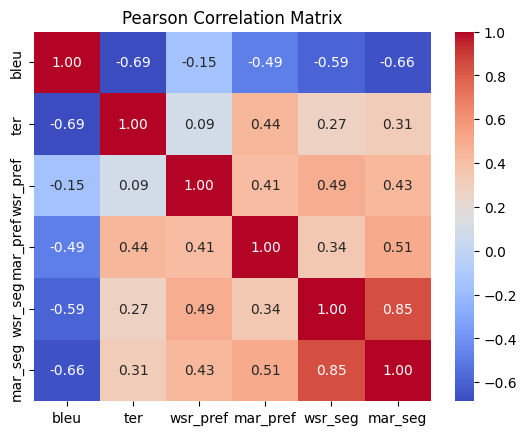

In [ ]:
drop_cols = ['modelo','src','trg', 'dif_mar', 'dif_wsr']
drop_df = new_df.drop(columns=drop_cols)
corr_matrix = drop_df.corr(method='pearson')

plt.figure()
sns.heatmap(corr_matrix, 
            annot=True, 
            cmap='coolwarm', 
            fmt='.2f')
plt.title('Pearson Correlation Matrix')
plt.show()

In [ ]:
corr_matrix

,bleu,ter,wsr_pref,mar_pref,wsr_seg,mar_seg
bleu,1.000000,-0.686591,-0.153331,-0.486192,-0.588580,-0.662401
ter,-0.686591,1.000000,0.085391,0.443973,0.268775,0.314825
wsr_pref,-0.153331,0.085391,1.000000,0.413832,0.492401,0.433992
mar_pref,-0.486192,0.443973,0.413832,1.000000,0.342443,0.505674
wsr_seg,-0.588580,0.268775,0.492401,0.342443,1.000000,0.847807
mar_seg,-0.662401,0.314825,0.433992,0.505674,0.847807,1.000000
